In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

In [8]:
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f8f8',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

df_def = pd.read_parquet('../data/lgd_dataset.parquet')

In [9]:
df_def['ead'] = (df_def['funded_amnt'] - df_def['total_rec_prncp']).clip(lower=0)
df_def['ccf'] = (df_def['ead'] / df_def['funded_amnt']).clip(0, 1)

print("=== EAD ===")
print(df_def['ead'].describe().round(2))
print(f"\nEAD media / funded_amnt media: {df_def['ead'].mean() / df_def['funded_amnt'].mean():.3f}")

print("\n=== CCF (Credit Conversion Factor) ===")
print(df_def['ccf'].describe().round(4))

=== EAD ===
count    116315.00
mean      11160.86
std        7809.69
min           0.00
25%        4979.16
50%        9457.04
75%       15593.36
max       40000.00
Name: ead, dtype: float64

EAD media / funded_amnt media: 0.714

=== CCF (Credit Conversion Factor) ===
count    116315.0000
mean          0.6932
std           0.2216
min           0.0000
25%           0.5595
50%           0.7440
75%           0.8706
max           1.0000
Name: ccf, dtype: float64


In [10]:
df_def['term_clean'] = df_def['term'].str.strip()

ccf_grade = (df_def.groupby('grade')['ccf']
             .agg(['mean', 'std', 'count'])
             .round(4)
             .reset_index())
ccf_grade.columns = ['grade', 'ccf_mean', 'ccf_std', 'n']

ccf_term = (df_def.groupby('term_clean')['ccf']
            .agg(['mean', 'std', 'count'])
            .round(4)
            .reset_index())
ccf_term.columns = ['term', 'ccf_mean', 'ccf_std', 'n']

ccf_grade_term = (df_def.groupby(['grade', 'term_clean'])['ccf']
                  .agg(['mean', 'std', 'count'])
                  .round(4)
                  .reset_index())
ccf_grade_term.columns = ['grade', 'term', 'ccf_mean', 'ccf_std', 'n']

print("\n=== CCF por Grade ===")
print(ccf_grade.to_string(index=False))

print("\n=== CCF por Term ===")
print(ccf_term.to_string(index=False))

print("\n=== CCF por Grade x Term ===")
print(ccf_grade_term.to_string(index=False))


=== CCF por Grade ===
grade  ccf_mean  ccf_std     n
    A    0.5853   0.2453  6207
    B    0.6210   0.2308 23031
    C    0.6795   0.2167 37429
    D    0.7211   0.2082 26331
    E    0.7656   0.1891 15285
    F    0.8103   0.1783  6113
    G    0.8455   0.1532  1919

=== CCF por Term ===
     term  ccf_mean  ccf_std     n
36 months    0.6386   0.2312 70476
60 months    0.7773   0.1754 45839

=== CCF por Grade x Term ===
grade      term  ccf_mean  ccf_std     n
    A 36 months    0.5791   0.2461  5900
    A 60 months    0.7037   0.1957   307
    B 36 months    0.6001   0.2330 19147
    B 60 months    0.7242   0.1886  3884
    C 36 months    0.6389   0.2256 24394
    C 60 months    0.7555   0.1754 13035
    D 36 months    0.6774   0.2213 14473
    D 60 months    0.7743   0.1770 11858
    E 36 months    0.7114   0.2164  5059
    E 60 months    0.7924   0.1676 10226
    F 36 months    0.7241   0.2230  1180
    F 60 months    0.8309   0.1591  4933
    G 36 months    0.7756   0.2014   32

In [12]:
ead_grade = (df_def.groupby('grade')['ead']
             .agg(['mean', 'median', 'std'])
             .round(2)
             .reset_index())

ead_grade_term = (df_def.groupby(['grade', 'term_clean'])['ead']
                  .agg(['mean', 'median'])
                  .round(2)
                  .reset_index())

print("\n=== EAD media por Grade x Term ===")
print(ead_grade_term.to_string(index=False))



=== EAD media por Grade x Term ===
grade term_clean     mean   median
    A  36 months  7830.19  6097.84
    A  60 months 14063.78 12547.59
    B  36 months  7442.55  5807.03
    B  60 months 15163.44 13689.34
    C  36 months  7904.98  6092.46
    C  60 months 15039.40 13677.50
    D  36 months  9012.14  6942.06
    D  60 months 15350.81 14127.70
    E  36 months  9590.78  7094.52
    E  60 months 16168.00 14970.68
    F  36 months  9231.08  6713.78
    F  60 months 17679.82 16667.03
    G  36 months 11283.85  8445.61
    G  60 months 18371.89 17248.75


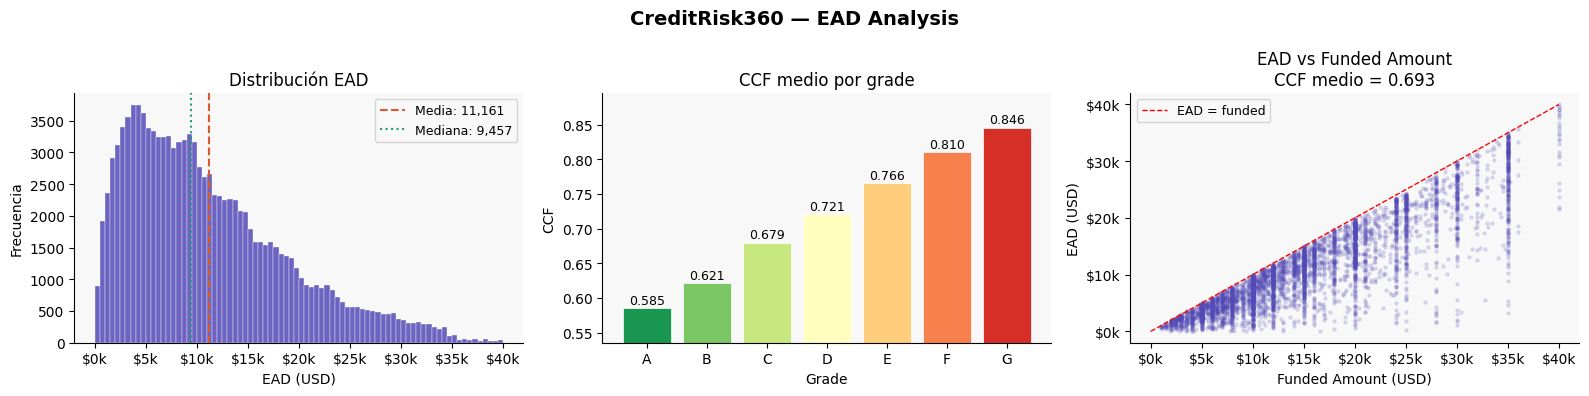

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('CreditRisk360 — EAD Analysis', fontsize=14, fontweight='bold')

# 4.1 Distribución EAD
ax = axes[0]
ax.hist(df_def['ead'], bins=80, color='#534AB7',
        edgecolor='white', linewidth=0.3, alpha=0.85)
ax.axvline(df_def['ead'].mean(), color='#D85A30', lw=1.5,
           linestyle='--', label=f"Media: {df_def['ead'].mean():,.0f}")
ax.axvline(df_def['ead'].median(), color='#1D9E75', lw=1.5,
           linestyle=':', label=f"Mediana: {df_def['ead'].median():,.0f}")
ax.set_title('Distribución EAD')
ax.set_xlabel('EAD (USD)')
ax.set_ylabel('Frecuencia')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
ax.legend(fontsize=9)

# 4.2 CCF por grade
ax = axes[1]
colors = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(ccf_grade)))
bars = ax.bar(ccf_grade['grade'], ccf_grade['ccf_mean'],
              color=colors, edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, ccf_grade['ccf_mean']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9)
ax.set_title('CCF medio por grade')
ax.set_xlabel('Grade')
ax.set_ylabel('CCF')
ax.set_ylim(ccf_grade['ccf_mean'].min() - 0.05,
            ccf_grade['ccf_mean'].max() + 0.05)

# 4.3 EAD vs funded_amnt scatter (muestra)
ax = axes[2]
sample = df_def.sample(5000, random_state=42)
ax.scatter(sample['funded_amnt'], sample['ead'],
           alpha=0.15, s=5, color='#534AB7')
ax.plot([0, 40000], [0, 40000], 'r--', lw=1, label='EAD = funded')
ax.set_title(f'EAD vs Funded Amount\nCCF medio = {df_def["ccf"].mean():.3f}')
ax.set_xlabel('Funded Amount (USD)')
ax.set_ylabel('EAD (USD)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/07_ead_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


In [15]:
ccf_grade_term.to_csv('../data/ead_ccf_table.csv', index=False)

# Dataset con EAD y CCF incorporados
df_def.to_parquet('../data/lgd_dataset.parquet', index=False)

# Dataset completo para Expected Loss (Notebook 08)
# Necesitamos PD del modelo de Semana 2 — preparar merge
print("\n=== Resumen EAD ===")
print(f"EAD media:          ${df_def['ead'].mean():>10,.2f}")
print(f"EAD mediana:        ${df_def['ead'].median():>10,.2f}")
print(f"CCF medio:          {df_def['ccf'].mean():>10.4f}")
print(f"EAD total portfolio:${df_def['ead'].sum():>10,.0f}")
print(f"\nArchivos guardados:")
print(f"  data/ead_ccf_table.csv")
print(f"  data/lgd_dataset.parquet (actualizado con ead, ccf)")


=== Resumen EAD ===
EAD media:          $ 11,160.86
EAD mediana:        $  9,457.04
CCF medio:              0.6932
EAD total portfolio:$1,298,175,741

Archivos guardados:
  data/ead_ccf_table.csv
  data/lgd_dataset.parquet (actualizado con ead, ccf)
